In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.preprocessing import StandardScaler , LabelEncoder
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier , VotingClassifier
from sklearn.metrics import accuracy_score

In [230]:
df = pd.read_csv(r"D:\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\Downloads\train.csv")
df.drop(columns=['PassengerId' , 'Name',  'Cabin'] , inplace=True)

df.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True


In [212]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HomePlanet    8693 non-null   int64  
 1   CryoSleep     8693 non-null   object 
 2   Destination   8693 non-null   object 
 3   Age           8693 non-null   float64
 4   VIP           8693 non-null   object 
 5   RoomService   8693 non-null   float64
 6   FoodCourt     8693 non-null   float64
 7   ShoppingMall  8693 non-null   float64
 8   Spa           8693 non-null   float64
 9   VRDeck        8693 non-null   float64
 10  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), int64(1), object(3)
memory usage: 687.8+ KB


In [217]:
df.isna().sum()

HomePlanet      201
CryoSleep       217
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Transported       0
dtype: int64

In [204]:
df[df['FoodCourt']>10000]

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported
105,Europa,False,TRAPPIST-1e,42.0,False,2209.0,11418.0,0.0,1868.0,445.0,True
154,Europa,False,TRAPPIST-1e,38.0,False,0.0,10346.0,1.0,14970.0,2111.0,False
358,Europa,False,55 Cancri e,31.0,True,0.0,11003.0,552.0,8157.0,5688.0,False
387,Europa,False,55 Cancri e,20.0,False,2.0,10116.0,0.0,2.0,225.0,True
474,Europa,False,TRAPPIST-1e,59.0,False,0.0,16521.0,0.0,323.0,0.0,True
725,Europa,False,55 Cancri e,36.0,False,29.0,12180.0,0.0,93.0,17306.0,False
764,Europa,False,55 Cancri e,36.0,True,0.0,13248.0,100.0,1953.0,1.0,True
832,Europa,False,55 Cancri e,27.0,NaN,1.0,12804.0,0.0,10.0,52.0,True
871,Europa,False,TRAPPIST-1e,30.0,False,14.0,12045.0,0.0,2121.0,0.0,True
1094,Europa,False,55 Cancri e,28.0,False,0.0,11330.0,72.0,43.0,461.0,True


In [231]:

for col in ['Age' , 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']:
    df[col] = df[col].fillna(df[col].median())

for col in ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']:
    df[col] = df[col].fillna('Unknown')
    df[col] = df[col].astype(str)


In [235]:
df.isna().sum()

HomePlanet      0
CryoSleep       0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Transported     0
dtype: int64

In [232]:
(df['HomePlanet']=='Earth').sum()

np.int64(4602)

In [233]:
df['CryoSleep'].unique()

array(['False', 'True', 'Unknown'], dtype=object)

In [234]:
planet_encoder = LabelEncoder()
CryoSleep_encoder = LabelEncoder()
Cabin_encoder = LabelEncoder()
Destination_encoder = LabelEncoder()
VIP_encoder = LabelEncoder()
Transported_encoder = LabelEncoder()

df['HomePlanet'] = planet_encoder.fit_transform(df['HomePlanet'])
df['CryoSleep'] = CryoSleep_encoder.fit_transform(df['CryoSleep'])
df['Destination'] = Destination_encoder.fit_transform(df['Destination'])
df['VIP'] = VIP_encoder.fit_transform(df['VIP'])
df['Transported'] = Transported_encoder.fit_transform(df['Transported'])

df.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported
0,1,0,2,39.0,0,0.0,0.0,0.0,0.0,0.0,0
1,0,0,2,24.0,0,109.0,9.0,25.0,549.0,44.0,1
2,1,0,2,58.0,1,43.0,3576.0,0.0,6715.0,49.0,0
3,1,0,2,33.0,0,0.0,1283.0,371.0,3329.0,193.0,0
4,0,0,2,16.0,0,303.0,70.0,151.0,565.0,2.0,1


In [237]:
df = df[df['RoomService'] < 9500]
df = df[df['FoodCourt'] < 20000]
df = df[df['ShoppingMall'] < 6000]
df = df[df['Spa'] < 15000]
df = df[df['VRDeck'] < 12500]

In [238]:
x = df.drop(columns=['Transported'])
y = df.iloc[: , -1]
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=42)

In [284]:
catboost_model = CatBoostClassifier(
    iterations=1500,
    learning_rate=0.01,
    depth=5,
    l2_leaf_reg=8,
    # bootstrap_type="Bayesian",
    # bagging_temperature=0.5,
    loss_function="Logloss",
    eval_metric="Accuracy",
    random_seed=42,
    # use_best_model=True,
    verbose=100,
)

catboost_model.fit(x_train , y_train , eval_set=(x_test , y_test) , use_best_model=True)

0:	learn: 0.7458484	test: 0.7269053	best: 0.7269053 (0)	total: 6.32ms	remaining: 9.47s
100:	learn: 0.7919134	test: 0.7881062	best: 0.7898383 (97)	total: 560ms	remaining: 7.75s
200:	learn: 0.7959567	test: 0.7938799	best: 0.7944573 (188)	total: 1.13s	remaining: 7.29s
300:	learn: 0.7963899	test: 0.7961894	best: 0.7973441 (262)	total: 1.69s	remaining: 6.73s
400:	learn: 0.7962455	test: 0.7967667	best: 0.7979215 (362)	total: 2.23s	remaining: 6.11s
500:	learn: 0.7979783	test: 0.7984988	best: 0.7996536 (463)	total: 2.76s	remaining: 5.5s
600:	learn: 0.7992780	test: 0.7956120	best: 0.7996536 (463)	total: 3.3s	remaining: 4.94s
700:	learn: 0.8005776	test: 0.8013857	best: 0.8019630 (689)	total: 3.84s	remaining: 4.38s
800:	learn: 0.8027437	test: 0.7990762	best: 0.8019630 (689)	total: 4.39s	remaining: 3.83s
900:	learn: 0.8047653	test: 0.8002309	best: 0.8019630 (689)	total: 4.93s	remaining: 3.27s
1000:	learn: 0.8069314	test: 0.8019630	best: 0.8019630 (689)	total: 5.46s	remaining: 2.72s
1100:	learn: 0.

In [264]:
xgb_model = XGBClassifier(
    n_estimators=1000,        # number of trees
    learning_rate=0.05,      # step size
    max_depth=5,             # tree depth
    subsample=0.7,           # row sampling
    colsample_bytree=0.8,    # feature sampling
    min_child_weight=1,      # minimum leaf weight
    gamma=5,                 # minimum loss reduction
    reg_lambda=8,          # L2 regularization
    reg_alpha=0.0,           # L1 regularization
    objective='binary:logistic',  # for binary classification
    eval_metric='logloss',
    n_jobs=8,                # use only 4 threads
    random_state=42          # ✅ removed trailing comma
)

xgb_model.fit(x_train, y_train, verbose=True)  # also safe

y_pred = xgb_model.predict(x_test)
accuracy = accuracy_score(y_test , y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7990762124711316


In [337]:
sample = pd.read_csv(r"D:\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\Downloads\sample_submission.csv")

test_df =  pd.read_csv(r"D:\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\Downloads\test.csv")
test_df.drop(columns=['PassengerId' , 'Name',  'Cabin'] , inplace=True)


for col in ['Age' , 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']:
    test_df[col] = test_df[col].fillna(test_df[col].median())

for col in ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']:
    test_df[col] = test_df[col].fillna('Unknown')
    test_df[col] = test_df[col].astype(str)

test_df['HomePlanet'] = planet_encoder.transform(test_df['HomePlanet'])
test_df['CryoSleep'] = CryoSleep_encoder.transform(test_df['CryoSleep'])
test_df['Destination'] = Destination_encoder.transform(test_df['Destination'])
test_df['VIP'] = VIP_encoder.transform(test_df['VIP'])

test_y_pred = xgb_model.predict(test_df)
submission = pd.DataFrame({
    'PassengerId' : sample['PassengerId'],
    'Transported' : Transported_encoder.inverse_transform(test_y_pred)                      
})
submission.to_csv('submission.csv' , index = False )

In [296]:
import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(
    boosting_type='gbdt',      # Gradient Boosting Decision Tree
    n_estimators=1000,          # Number of trees
    learning_rate=0.01,        # Step size
    max_depth=8,               # Max tree depth
    # num_leaves=31,             # Maximum number of leaves per tree
    # min_child_samples=20,      # Minimum data in leaf
    subsample=0.7,             # Row sampling
    colsample_bytree=0.9,      # Feature sampling
    reg_alpha=0.0,             # L1 regularization
    reg_lambda=1,            # L2 regularization
    n_jobs=4,                  # Use 4 CPU threads
    random_state=42,
    verbose = 0
)

# Train the model
lgb_model.fit(x_train, y_train )

y_pred = lgb_model.predict(x_test)
accuracy = accuracy_score(y_test , y_pred)
print("Accuracy:", accuracy)

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [311]:
rf_model = RandomForestClassifier(
    n_estimators=500,       # number of trees
    max_depth=10,         # expand nodes until all leaves are pure
    min_samples_split=5,    # minimum samples to split a node
    min_samples_leaf=10,     # minimum samples in a leaf
    max_features=0.7,    # number of features to consider at each split
    bootstrap=True,         # use bootstrap samples
    n_jobs=-1,               # use 4 CPU threads
    random_state=42,
    max_samples=0.7
    # max_samples=None
)

# Train the model
rf_model.fit(x_train, y_train)

y_pred = rf_model.predict(x_test)
accuracy = accuracy_score(y_test , y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7979214780600462


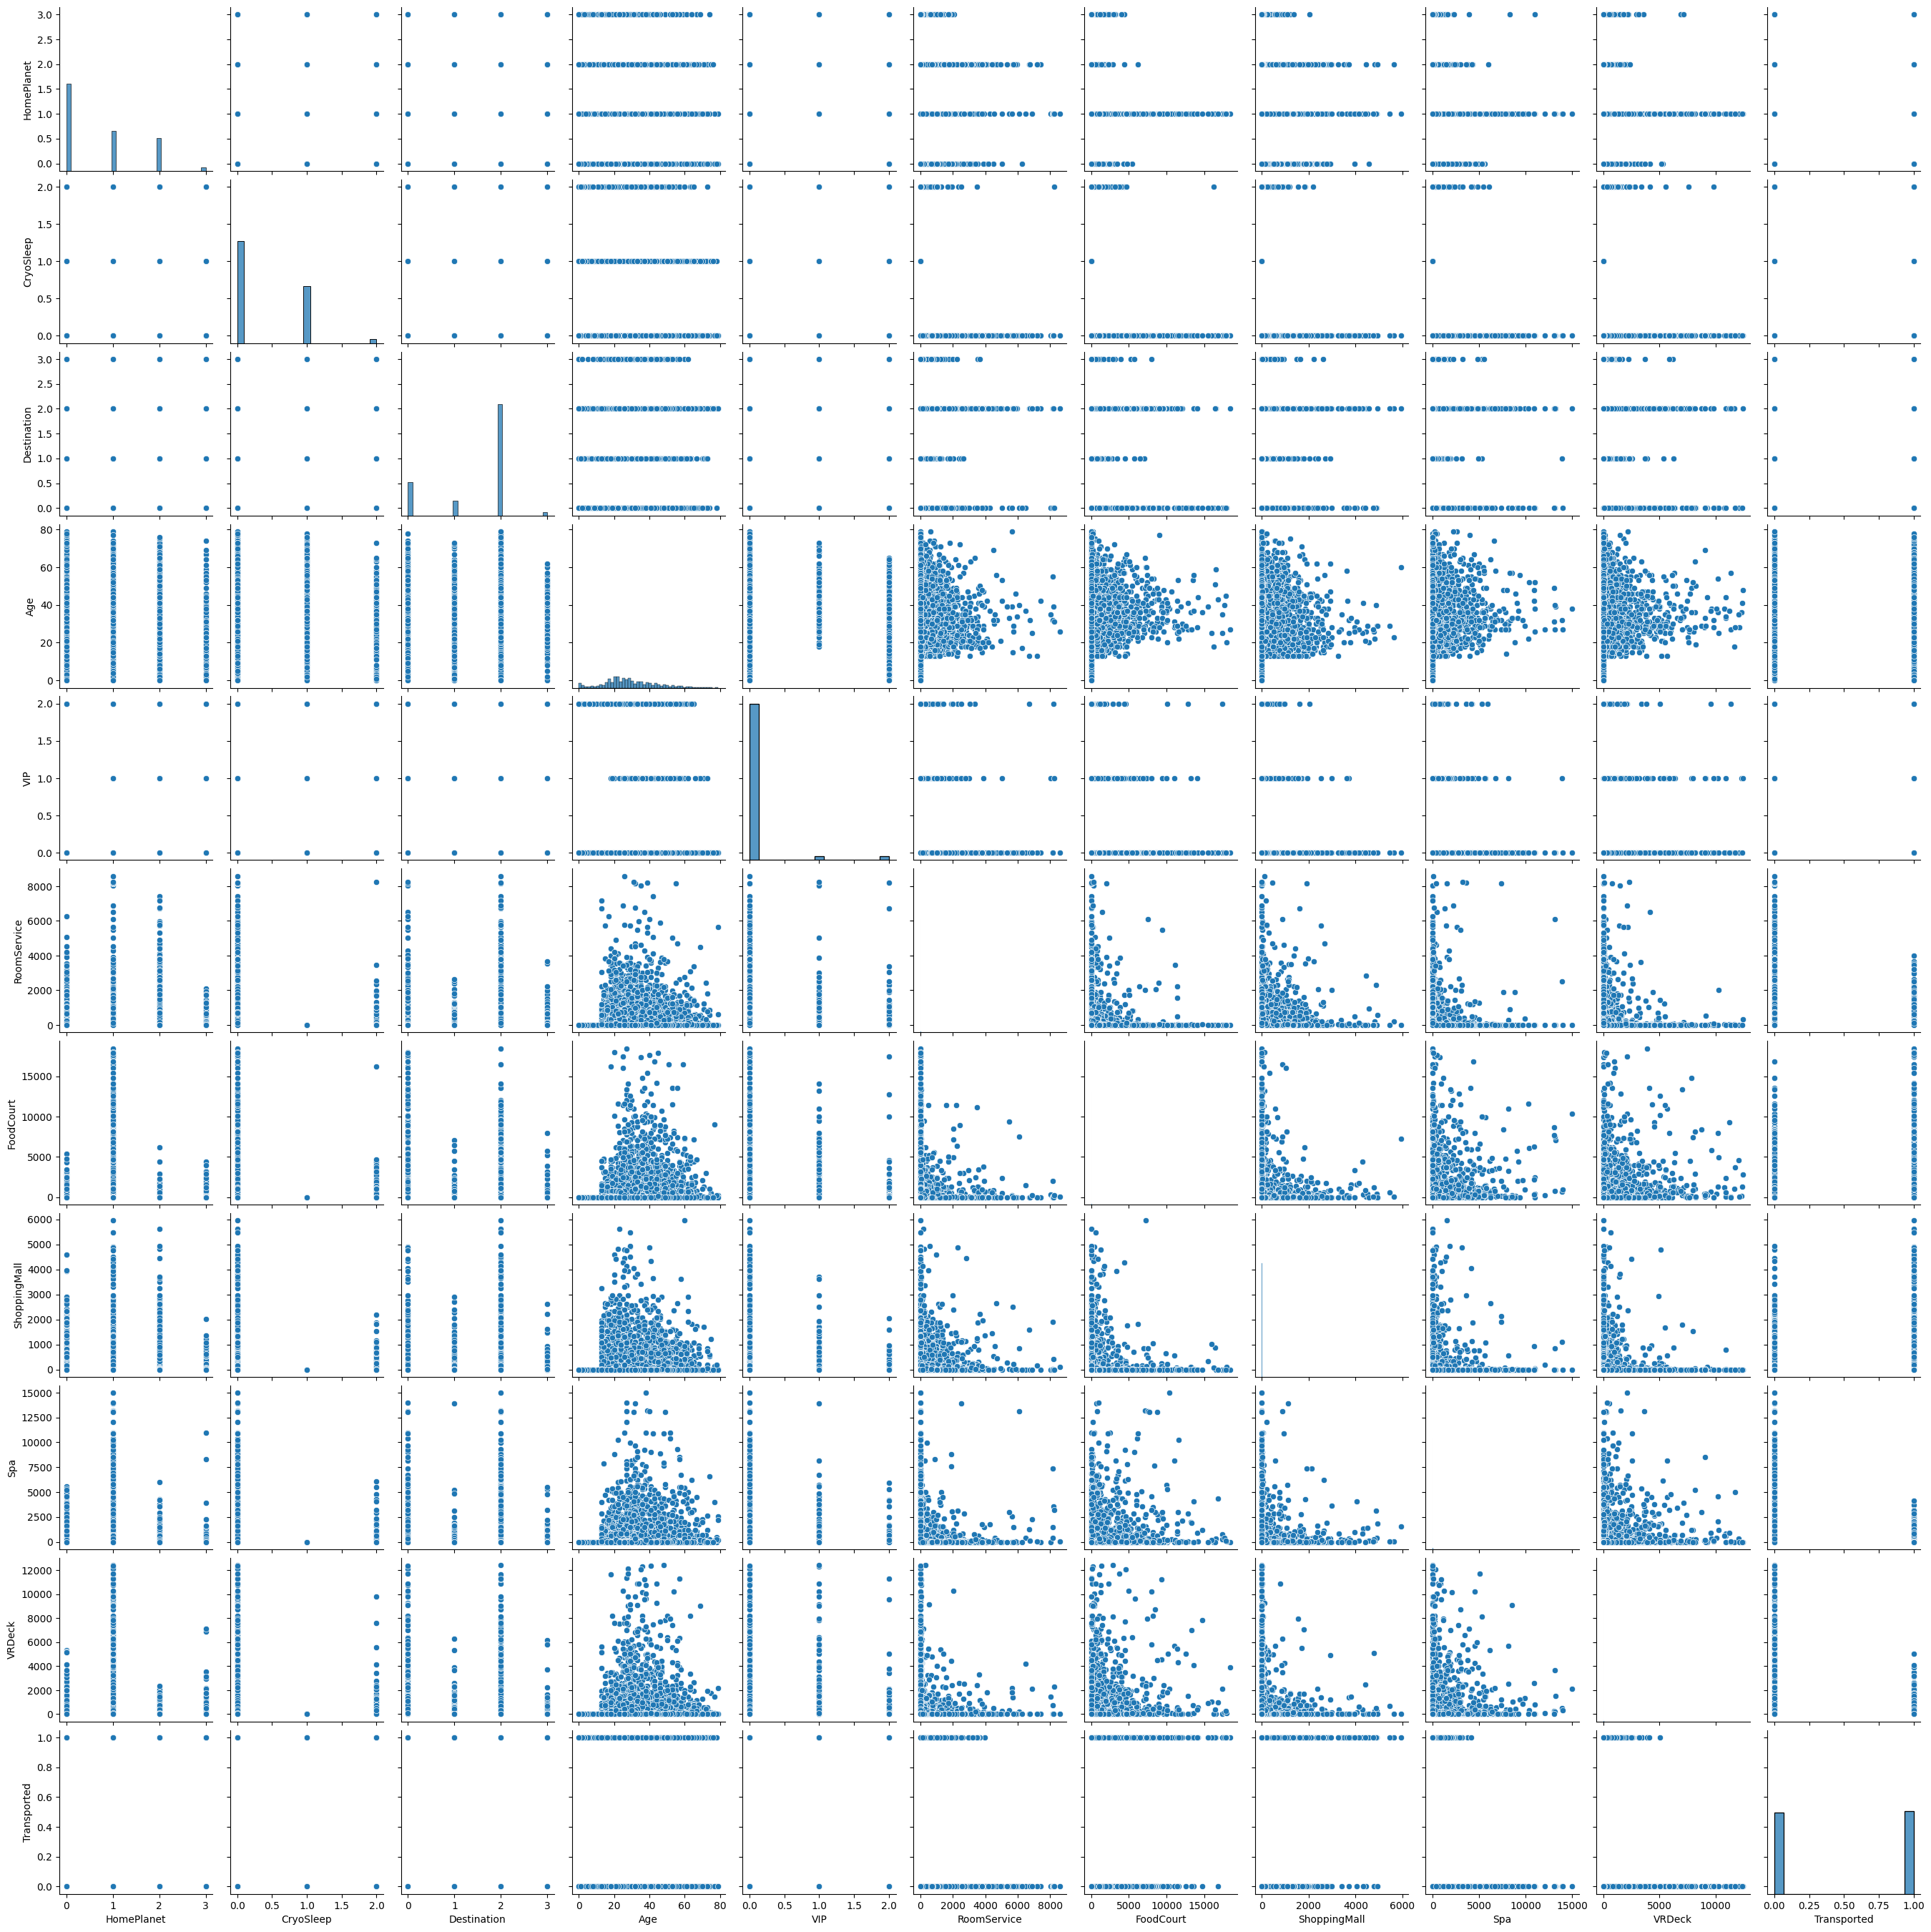

In [315]:
sns.pairplot(df)

In [321]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LogisticRegression

# Example dataset
# X = features, y = target
# Replace with your actual dataset
X = df.drop('Transported', axis=1)  # features
y = df['Transported']               # target

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features (important when using polynomial features)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Generate polynomial features
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

# Initialize Logistic Regression
logreg = LogisticRegression(max_iter=1000, solver='lbfgs')

# Train the model
logreg.fit(X_train_poly, y_train)

# Predict
y_pred = logreg.predict(X_test_poly)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.7944572748267898


In [332]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Example: X = features, y = target
# Replace X, y with your actual data
# X = df.drop('Transported', axis=1)
# y = df['Transported']

# Initialize the SVC
svc_model = SVC(kernel='rbf', C=5.0, gamma='scale', random_state=42)

# Fit the model
svc_model.fit(x_train, y_train)

# Predict on the same data
y_pred = svc_model.predict(x_test)

# Print accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")


Accuracy: 0.796189376443418


In [334]:
sample = pd.read_csv(r"D:\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\Downloads\sample_submission.csv")

test_df =  pd.read_csv(r"D:\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\Downloads\test.csv")
test_df.drop(columns=['PassengerId' , 'Name',  'Cabin'] , inplace=True)


for col in ['Age' , 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']:
    test_df[col] = test_df[col].fillna(test_df[col].median())

for col in ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']:
    test_df[col] = test_df[col].fillna('Unknown')
    test_df[col] = test_df[col].astype(str)

test_df['HomePlanet'] = planet_encoder.transform(test_df['HomePlanet'])
test_df['CryoSleep'] = CryoSleep_encoder.transform(test_df['CryoSleep'])
test_df['Destination'] = Destination_encoder.transform(test_df['Destination'])
test_df['VIP'] = VIP_encoder.transform(test_df['VIP'])

test_y_pred = svc_model.predict(test_df)
submission = pd.DataFrame({
    'PassengerId' : sample['PassengerId'],
    'Transported' : Transported_encoder.inverse_transform(test_y_pred)                      
})
submission.to_csv('submission.csv' , index = False )

In [333]:


voting_clf = VotingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('lgb', lgb_model),
        ('cat', catboost_model),
        ('rf', rf_model),
        ('svc', svc_model)
    ],
    voting='soft'   # 'soft' = use predicted probabilities; 'hard' = use predicted classes
)

# 3️⃣ Train the Voting Classifier
voting_clf.fit(x_train, y_train)

# 4️⃣ Predict and Evaluate
y_pred = voting_clf.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print("Voting Classifier Accuracy:", accuracy)

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

AttributeError: This 'SVC' has no attribute 'predict_proba'

In [314]:
sample = pd.read_csv(r"D:\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\Downloads\sample_submission.csv")

test_df =  pd.read_csv(r"D:\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\Downloads\test.csv")
test_df.drop(columns=['PassengerId' , 'Name',  'Cabin'] , inplace=True)


for col in ['Age' , 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']:
    test_df[col] = test_df[col].fillna(test_df[col].median())

for col in ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']:
    test_df[col] = test_df[col].fillna('Unknown')
    test_df[col] = test_df[col].astype(str)

test_df['HomePlanet'] = planet_encoder.transform(test_df['HomePlanet'])
test_df['CryoSleep'] = CryoSleep_encoder.transform(test_df['CryoSleep'])
test_df['Destination'] = Destination_encoder.transform(test_df['Destination'])
test_df['VIP'] = VIP_encoder.transform(test_df['VIP'])

test_y_pred = voting_clf.predict(test_df)
submission = pd.DataFrame({
    'PassengerId' : sample['PassengerId'],
    'Transported' : Transported_encoder.inverse_transform(test_y_pred)                      
})
submission.to_csv('submission.csv' , index = False )

In [352]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense , Dropout , Flatten , Input , BatchNormalization

In [376]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

model = Sequential()

model.add(Input(shape=(x_train.shape[1],)))

model.add(Dense(64 , activation = 'relu' , kernel_regularizer=tf.keras.regularizers.L2(0.001)))
model.add(BatchNormalization())

model.add(Dense(64 , activation = 'tanh' , kernel_regularizer=tf.keras.regularizers.L2(0.001)))
model.add(BatchNormalization())

model.add(Dense(64 , activation = 'relu' , kernel_regularizer=tf.keras.regularizers.L2(0.005)))
model.add(BatchNormalization())

model.add(Dense(32 , activation = 'tanh' , kernel_regularizer=tf.keras.regularizers.L2(0.01)))
model.add(BatchNormalization())

model.add(Dense(1 , activation = 'sigmoid'))

# model.summary()

model.compile(loss = 'binary_crossentropy' , optimizer = tf.keras.optimizers.Adam(learning_rate=0.005) , metrics = ['accuracy'])

In [377]:
history = model.fit(x_train_scaled ,y_train , batch_size=32 , validation_data = (x_test_scaled , y_test) , epochs=100 )

Epoch 1/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7560 - loss: 0.8753 - val_accuracy: 0.7956 - val_loss: 0.6106
Epoch 2/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7743 - loss: 0.5606 - val_accuracy: 0.7667 - val_loss: 0.5202
Epoch 3/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7772 - loss: 0.5188 - val_accuracy: 0.7916 - val_loss: 0.4777
Epoch 4/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7806 - loss: 0.5032 - val_accuracy: 0.7910 - val_loss: 0.4798
Epoch 5/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7776 - loss: 0.4938 - val_accuracy: 0.7893 - val_loss: 0.4611
Epoch 6/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7804 - loss: 0.4890 - val_accuracy: 0.7829 - val_loss: 0.5251
Epoch 7/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7806 - loss: 0.4959 - val_accuracy: 0.7812 - val_loss: 0.4976
Epoch 8/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7844 - loss: 0.4846 - val_accu

In [378]:
y_pred_prob = model.predict(x_test_scaled)
y_pred = np.where(y_pred_prob > 0.5 , True , False)
accuracy_score(y_test , y_pred)

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


0.8002309468822171

In [381]:
sample = pd.read_csv(r"D:\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\Downloads\sample_submission.csv")

test_df =  pd.read_csv(r"D:\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\Downloads\test.csv")
test_df.drop(columns=['PassengerId' , 'Name',  'Cabin'] , inplace=True)


for col in ['Age' , 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']:
    test_df[col] = test_df[col].fillna(test_df[col].median())

for col in ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']:
    test_df[col] = test_df[col].fillna('Unknown')
    test_df[col] = test_df[col].astype(str)

test_df['HomePlanet'] = planet_encoder.transform(test_df['HomePlanet'])
test_df['CryoSleep'] = CryoSleep_encoder.transform(test_df['CryoSleep'])
test_df['Destination'] = Destination_encoder.transform(test_df['Destination'])
test_df['VIP'] = VIP_encoder.transform(test_df['VIP'])

test_df_scaled = scaler.transform(test_df)

test_y_pred_prob = model.predict(test_df_scaled)
test_y_pred = np.where(test_y_pred_prob > 0.5 , True , False)

submission = pd.DataFrame({
    'PassengerId' : sample['PassengerId'],
    'Transported' : test_y_pred.flatten()
})
submission.to_csv('submission.csv' , index = False )

134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


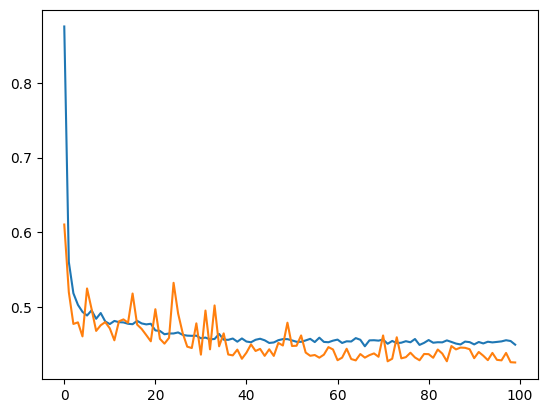

In [379]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

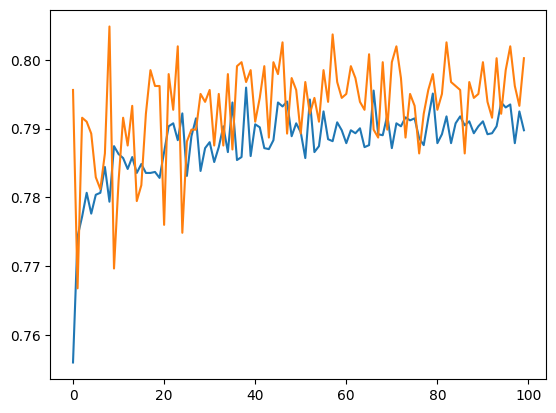

In [380]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])